In [1]:
from bs4 import BeautifulSoup

In [108]:
def parse_active_teams(html: str) -> list[dict]:
    soup = BeautifulSoup(html, "html.parser")

    teams = []
    for table_id in ("standings_EAS", "standings_WES"):
        table = soup.find("table", {"id": table_id})
        if not table:
            continue

        for row in table.select("tr.full_table"):
            name_cell = row.find(["th", "td"], {"data-stat": "team_name"})
            if not name_cell:
                continue

            anchor = name_cell.find("a", href=True)
            if not anchor:
                continue

            full_name = anchor.text.strip().rstrip("*")
            abbreviation = anchor["href"].split("/")[2]

            teams.append({"full_name": full_name, "abbreviation": abbreviation})

    return teams

In [109]:
import requests

In [110]:
response = requests.get("https://www.hockey-reference.com/leagues/NHL_2026.html")

In [111]:
teams = parse_active_teams(response.text)

In [112]:
teams

[{'full_name': 'Buffalo Sabres', 'abbreviation': 'BUF'},
 {'full_name': 'Tampa Bay Lightning', 'abbreviation': 'TBL'},
 {'full_name': 'Montreal Canadiens', 'abbreviation': 'MTL'},
 {'full_name': 'Boston Bruins', 'abbreviation': 'BOS'},
 {'full_name': 'Ottawa Senators', 'abbreviation': 'OTT'},
 {'full_name': 'Detroit Red Wings', 'abbreviation': 'DET'},
 {'full_name': 'Toronto Maple Leafs', 'abbreviation': 'TOR'},
 {'full_name': 'Florida Panthers', 'abbreviation': 'FLA'},
 {'full_name': 'Carolina Hurricanes', 'abbreviation': 'CAR'},
 {'full_name': 'Pittsburgh Penguins', 'abbreviation': 'PIT'},
 {'full_name': 'Columbus Blue Jackets', 'abbreviation': 'CBJ'},
 {'full_name': 'New York Islanders', 'abbreviation': 'NYI'},
 {'full_name': 'Philadelphia Flyers', 'abbreviation': 'PHI'},
 {'full_name': 'Washington Capitals', 'abbreviation': 'WSH'},
 {'full_name': 'New Jersey Devils', 'abbreviation': 'NJD'},
 {'full_name': 'New York Rangers', 'abbreviation': 'NYR'},
 {'full_name': 'Colorado Avalanch

In [14]:
abv = teams[0]["abbreviation"]
url = f'https://www.hockey-reference.com/teams/{abv}/2026.html'

In [18]:
url

'https://www.hockey-reference.com/teams/ANA/2026.html'

'\n<!DOCTYPE html>\n<html data-version="klecko-" data-root="/home/hr/build" lang="en" class="no-js" >\n<head>\n    <meta charset="utf-8">\n    <meta http-equiv="x-ua-compatible" content="ie=edge">\n    <meta name="viewport" content="width=device-width, initial-scale=1.0, maximum-scale=2.0" />\n    <link rel="dns-prefetch" href="https://cdn.ssref.net/req/202603251" />\n<script>\n/* https://docs.osano.com/hc/en-us/articles/22469433444372-Google-Consent-Mode-v2  */\n  window.dataLayer = window.dataLayer ||[];\n      function gtag(){dataLayer.push(arguments);}\n      gtag(\'consent\',\'default\',{\n        \'ad_storage\':\'denied\',\n        \'analytics_storage\':\'denied\',\n        \'ad_user_data\':\'denied\',\n        \'ad_personalization\':\'denied\',\n        \'personalization_storage\':\'denied\',\n        \'functionality_storage\':\'granted\',\n        \'security_storage\':\'granted\',\n        \'wait_for_update\': 500\n      });\n      gtag("set", "ads_data_redaction", true);\n</sc
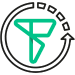
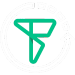

In [17]:
response = requests.get(url)
response.text

In [40]:
STATS_TO_KEEP = [
    "goals", "assists", "pen_min", "shots",
    "blocks", "hits", "takeaways", "giveaways"
]

def parse_player_stats(html: str) -> list[dict]:
    soup = BeautifulSoup(html, "html.parser")
    table = soup.find("table", {"id": "player_stats"})

    players = []
    for row in table.select("tbody tr"):
        # skip goalies
        pos = row.find("td", {"data-stat": "pos"})
        if not pos or pos.text.strip() == "G":
            continue

        name_cell = row.find("td", {"data-stat": "name_display"})
        player_id = name_cell.get("data-append-csv", "").strip()
        name = name_cell.text.strip()

        games_cell = row.find("td", {"data-stat": "games"})
        games = int(games_cell.text.strip() or 0)

        # use csk attribute for TOI (decimal minutes, easier to work with)
        toi_cell = row.find("td", {"data-stat": "time_on_ice"})
        toi = float(toi_cell.get("csk", 0) or 0)

        stats = {"player_id": player_id, "name": name, "pos": pos.text.strip(), "games": games, "toi": toi}

        for stat in STATS_TO_KEEP:
            cell = row.find("td", {"data-stat": stat})
            stats[stat] = int(cell.text.strip() or 0) if cell else 0

        players.append(stats)

    return players

In [45]:
players = parse_player_stats(response.text)

In [58]:
import pandas as pd
df = pd.DataFrame(players)
df['team'] = abv

In [59]:
df

,player_id,name,pos,games,toi,goals,assists,pen_min,shots,blocks,hits,takeaways,giveaways,team
0,gauthcu01,Cutter Gauthier,LW,70,1220.466667,36,26,26,261,20,57,18,69,ANA
1,carlsle01,Leo Carlsson,C,59,1130.633333,24,36,31,153,20,12,24,68,ANA
2,sennebe01,Beckett Sennecke,F,71,1244.016667,21,34,50,171,22,85,21,80,ANA
3,terrytr01,Troy Terry,C,51,932.866667,17,35,12,122,15,0,22,41,ANA
4,lacomja01,Jackson LaCombe,D,71,1723.050000,9,41,19,135,117,63,45,91,ANA
5,kreidch01,Chris Kreider,LW,65,1106.200000,22,24,26,120,19,58,16,60,ANA
6,mctavma01,Mason McTavish,C,64,1002.066667,14,20,40,124,31,77,14,47,ANA
7,troubja01,Jacob Trouba,D,70,1602.400000,10,22,31,144,133,121,21,75,ANA
8,granlmi01,Mikael Granlund,C,47,884.050000,16,15,18,93,30,25,17,37,ANA
9,poehlry01,Ryan Poehling,C,64,957.766667,9,22,8,76,73,38,14,44,ANA
